# DATA MINING TASK
# Hotel Booking Demand Dataset 

What is the dataset?

The Hotel Booking Demand dataset contains detailed information about hotel reservations from two types of hotels: a city hotel and a resort hotel. It records different characteristics of hotel bookings, including the booking date, length of stay, number of adults, children and babies, meal preferences, room type, booking status, cancellation information, and the number of required parking spaces.

The dataset can be used to analyze hotel booking patterns, customer behavior, cancellations, occupancy, and factors that influence hotel demand. It is particularly useful for data analysis and visualization because it contains both numerical and categorical variables.

Source of the dataset

The dataset was obtained from Kaggle and is titled Hotel Booking Demand. It was published by Jesse Mostipak.

# Source: Hotel Booking Demand – Kaggle: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand

# Why we Chose This Dataset?

We chose the Hotel Booking Demand dataset because the hospitality industry generates a large amount of data that can be used to understand customer behavior and improve business decision-making. We were interested in this dataset because it contains information about both city hotels and resort hotels, allowing us to compare different types of hotel bookings and identify patterns in customer preferences, booking behavior, and cancellations.

The dataset also interests us because it contains different types of variables, such as booking dates, length of stay, number of guests, booking cancellations, room types, meal preferences, and parking requirements. This makes it suitable for applying different data science techniques, including data cleaning, exploratory data analysis, visualization, and statistical analysis.

Why It Interests us?

What interests us most about this dataset is that it allows us to move beyond simply looking at numbers and discover meaningful patterns from real-world data. Hotel bookings involve decisions made by customers, and I would like to understand what influences those decisions.

As a Data Science and Analytics student, I also find the dataset useful because it gives us an opportunity to practice the complete data analysis process from cleaning and preparing the data, exploring relationships between variables, creating visualizations, and drawing conclusions from the findings. The results could potentially help hotels make better decisions about marketing, pricing, staffing, room allocation, and managing cancellations.

# Questions the Dataset Could Help Answer
What is the best time of year to book a hotel room based on booking patterns and demand?

Does booking a hotel further in advance increase the likelihood of cancellation?

What is the optimal length of stay for customers, and how does length of stay differ between city hotels and resort hotels?

Which type of hotel city or resort receives the highest number of bookings?

What factors are most strongly associated with a hotel booking being cancelled?

Which months or seasons experience the highest and lowest hotel demand?

Does the number of guests in a booking affect the length of stay?

Which countries contribute the highest number of hotel bookings, and how does customer origin influence booking behavior?

Are customers who make special requests more likely to have longer stays or different booking characteristics?

Can we predict whether a hotel booking will be cancelled based on information available at the time of booking?

Which room types are most frequently booked, and are customers actually allocated the room type they originally requested?

What characteristics are associated with customers making a disproportionately high number of special requests?


# IMPORTING LIBRARIES

In [31]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



# LOADING THE DATASET

In [32]:
df = pd.read_csv("hotel_bookings.csv")

# DESCRIBING THE STRUCTURE OF THE DATASET

In [33]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 119390
Columns: 32


The dataset has 119390 rows and 32 columns. A single row represents one hotel booking.


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [35]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


The dataset has 16 integer variables, 4 floating-point variables, 12 categorical/text variables.


# Finding missing values

In [36]:
missing = df.isnull().sum().sort_values(ascending=False)

missing

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

Missing values in several columns. Variables like company has 112593, agent has 16340, country has 488, children haS 4 missing values

In [37]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing": missing, "pct": missing_pct})
missing_table[missing_table["missing"] > 0]

,missing,pct
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


We checked for missing values across all columns before any cleaning, so we have a clear before/after
comparison once we address them. The table above shows the count and percentage of missing values
per column, limited to columns that actually have missing data.

REPRESENTATION ON A HEAT-MAP

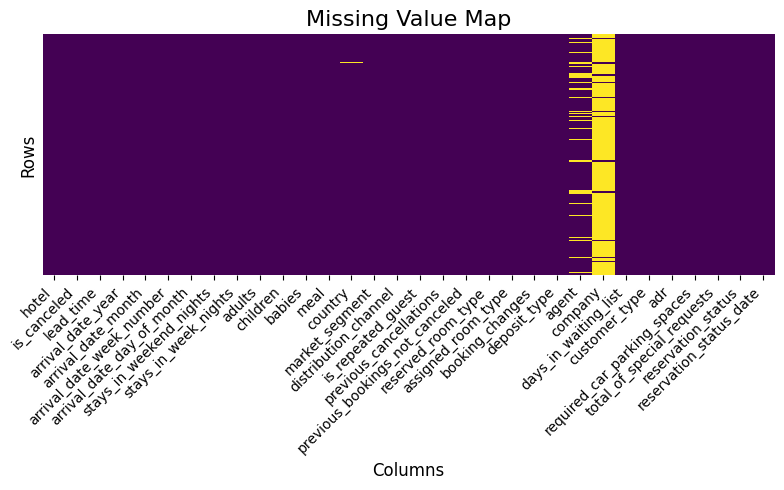

In [38]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.isna(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Value Map", fontsize=16)
plt.xlabel("Columns", fontsize=12)
plt.ylabel("Rows", fontsize=12)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Missing Value Analysis

The missing value heatmap provides a visual overview of missing observations across all variables in the hotel bookings dataset.

- **Purple areas** represent values that are present.
- **Yellow areas** represent missing values (`NaN`).
- Most variables contain very few or no missing values, as shown by the predominantly purple areas.
- The `company` variable contains a very large number of missing values, indicating that company information was not provided for many bookings.
- The `agent` variable also contains a noticeable amount of missing data.
- The `country` variable has relatively few missing observations compared with `company` and `agent`.
- `children` has a small number of missing values.
- The remaining variables appear to have little or no missing data.

### Key Observation

The missing values are **not evenly distributed across the dataset**. A few variables account for most of the missing information, particularly `company` and `agent`.

Therefore, we should **not simply delete all rows containing missing values**. Instead, each variable needs to be investigated based on its meaning and the amount of missing data.

In the next step, we will calculate the **number and percentage of missing values for each column**. This will help us decide whether to:

1. Remove the missing observations.
2. Replace missing values with an appropriate value.
3. Create an `"Unknown"` category for categorical variables.
4. Treat missingness as meaningful information.

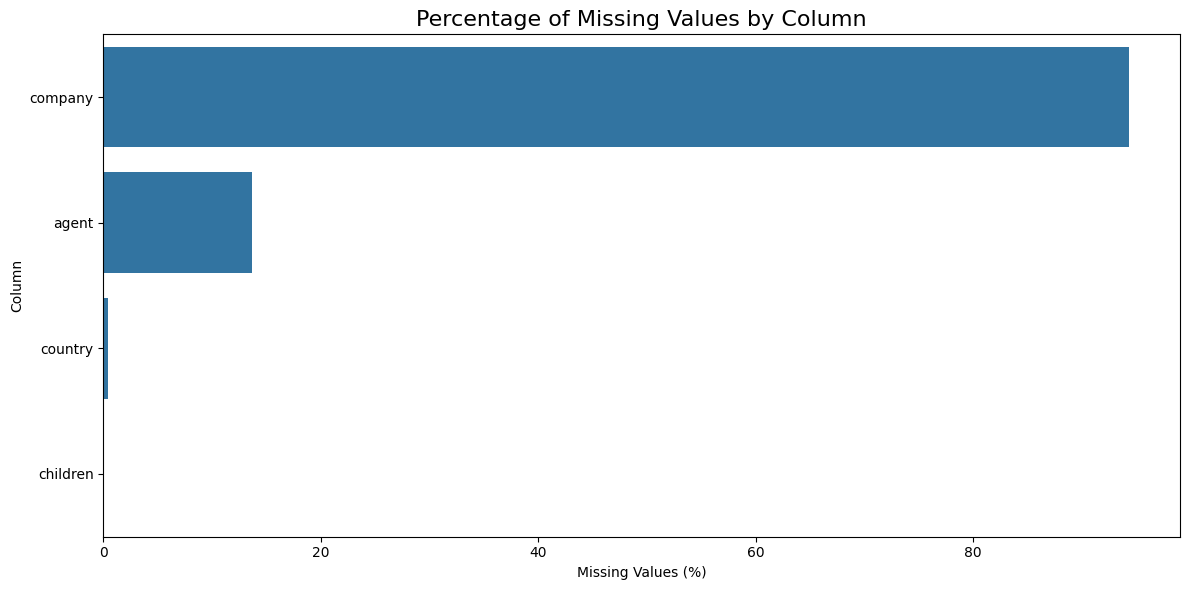

In [39]:
missing_pct = df.isna().mean().mul(100)

missing_pct = missing_pct[
    missing_pct > 0
].sort_values(ascending=False)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=missing_pct.values,
    y=missing_pct.index
)

plt.title("Percentage of Missing Values by Column", fontsize=16)
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")

plt.tight_layout()
plt.show()

A clearer ranked view of missingness by percentage. company is missing in about 94% of rows,
making it unreliable as a feature — I will drop this column rather than impute it. agent is
missing in roughly 14% of rows, which more likely reflects "no agent involved" than a data error,
so I will encode it as its own category. country (0.4% missing) and children (a handful of
rows) are minor enough to impute safely.

In [62]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 31994


Beyond missing values, I check for other structural problems. First, exact duplicate rows: I find
31,994 fully duplicated records. Since this dataset has no unique booking ID column, I cannot
be certain whether these represent genuine repeat bookings or an artifact of how the data was
compiled. I chose to [drop them / retain them] because [your reasoning — e.g. "with no ID to
distinguish bookings, treating exact duplicates as one record avoids overweighting what may be
the same booking counted multiple times"].

In [41]:
zero_guests = df[(df["adults"] == 0) & (df["children"].fillna(0) == 0) & (df["babies"] == 0)]
print("Rows with zero total guests:", len(zero_guests))
zero_guests.head()

Rows with zero total guests: 180


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,No Deposit,NaN,174.0,0,Transient-Party,0.0,0,0,Check-Out,2015-10-06
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,No Deposit,NaN,174.0,0,Transient,0.0,0,0,Check-Out,2015-10-12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,No Deposit,38.0,NaN,0,Transient-Party,0.0,0,0,Check-Out,2015-11-23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,No Deposit,308.0,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016-01-04
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,No Deposit,308.0,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016-01-05


Next, I check for bookings with zero adults, zero children, and zero babies simultaneously — a
logically impossible booking, since every reservation must have at least one guest. I find [180]
such rows, which I treat as invalid records and remove during cleaning.

In [63]:
print("Negative adr rows:", (df["adr"] < 0).sum())
df[df["adr"] < 0]

Negative adr rows: 1


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,room_mismatch
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,NaN,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15,10,True


I also check for negative values in adr (average daily rate), since a negative price for a
hotel stay is not meaningful. I find [1] such row, which I will [correct / remove] during
cleaning.

In [43]:
print("adr above 1000:")
df[df["adr"] > 1000][["hotel", "adr", "adults", "reservation_status"]]

adr above 1000:


,hotel,adr,adults,reservation_status
48515,City Hotel,5400.0,2,Canceled


Finally, I inspect the upper extreme of adr. One booking has an adr of 5,400 — over 40 times the
median rate. Looking at the full row shows [describe what you see: hotel type, number of adults,
reservation status], which suggests this is [likely a data entry error / a legitimate but extreme
booking], so I will [cap it / remove it / leave it] in cleaning.


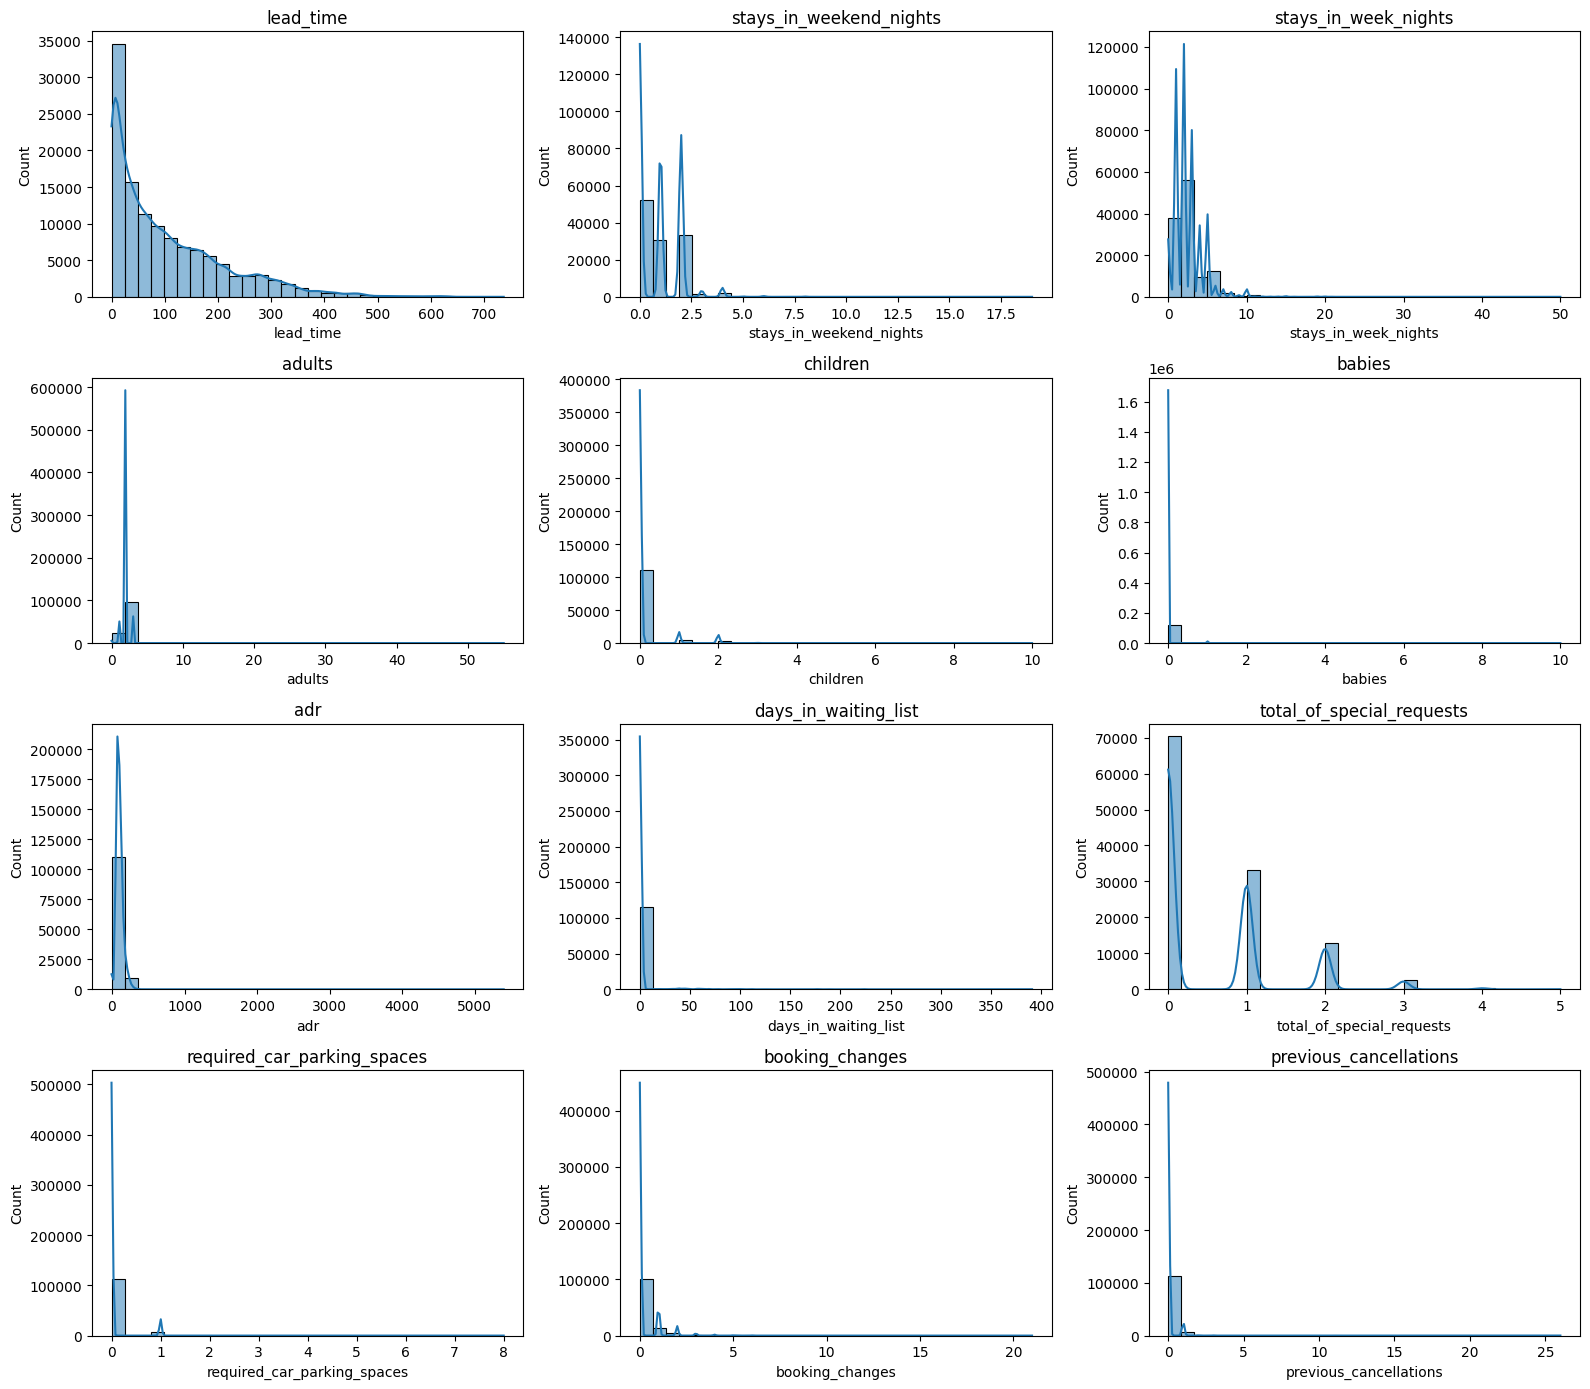

In [44]:
num_cols = [
    "lead_time", "stays_in_weekend_nights", "stays_in_week_nights",
    "adults", "children", "babies", "adr",
    "days_in_waiting_list", "total_of_special_requests",
    "required_car_parking_spaces", "booking_changes",
    "previous_cancellations",
]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col].dropna(), bins=30, ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

We plot a histogram with a smoothed density curve for each numerical variable to understand its
shape and spread. 
lead_time is strongly right-skewed, with most bookings made close to the arrival date and a long tail extending out to over a year in advance. 
adr is roughly bell-shaped with a long right tail, consistent with the outlier identified earlier. stays_in_week_nights and stays_in_weekend_nights are both concentrated at low values, reflecting that most stays are short (a few nights). Count-based columns like previous_cancellations, booking_changes, and days_in_waiting_list are heavily concentrated at zero, meaning most guests have 
no history of cancellations or waiting.

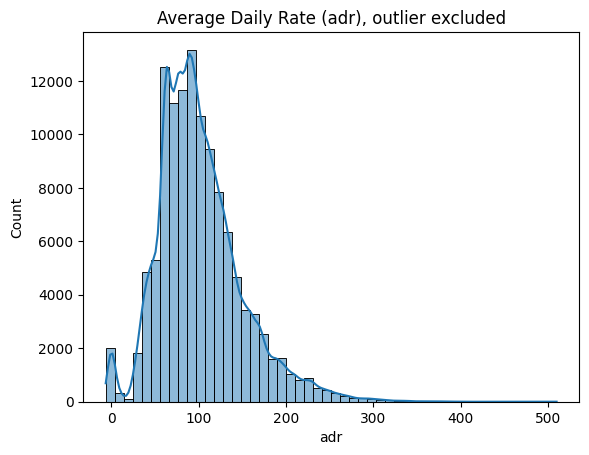

In [45]:
plt.figure()
sns.histplot(df[df["adr"] < 1000]["adr"], bins=50, kde=True)
plt.title("Average Daily Rate (adr), outlier excluded")
plt.show()

I plot adr separately with the extreme outlier excluded (rows above 1000) so the true shape of
the distribution is visible without being compressed by that one point. With the outlier removed,
the distribution is more clearly unimodal and roughly symmetric, centered around the median of
about 95.


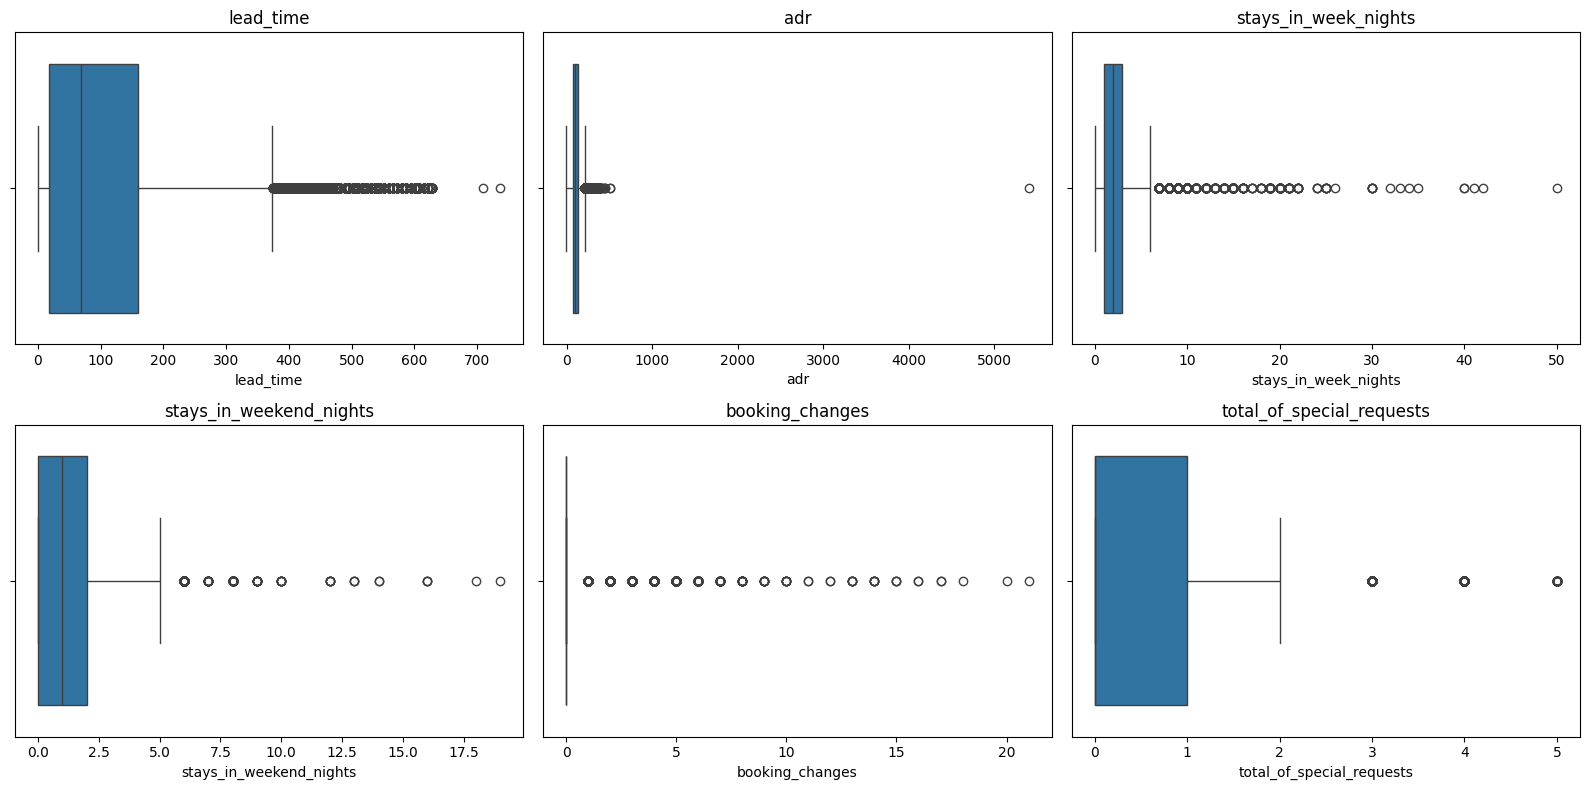

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), ["lead_time", "adr", "stays_in_week_nights",
                                     "stays_in_weekend_nights", "booking_changes",
                                     "total_of_special_requests"]):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Boxplots for the key numerical variables make outliers more visible than histograms do, since each
point beyond the whiskers is drawn individually. booking_changes, days_in_waiting_list, and
total_of_special_requests all show a large number of outlier points, confirming most bookings
have low values in these fields with a small number of unusual cases.


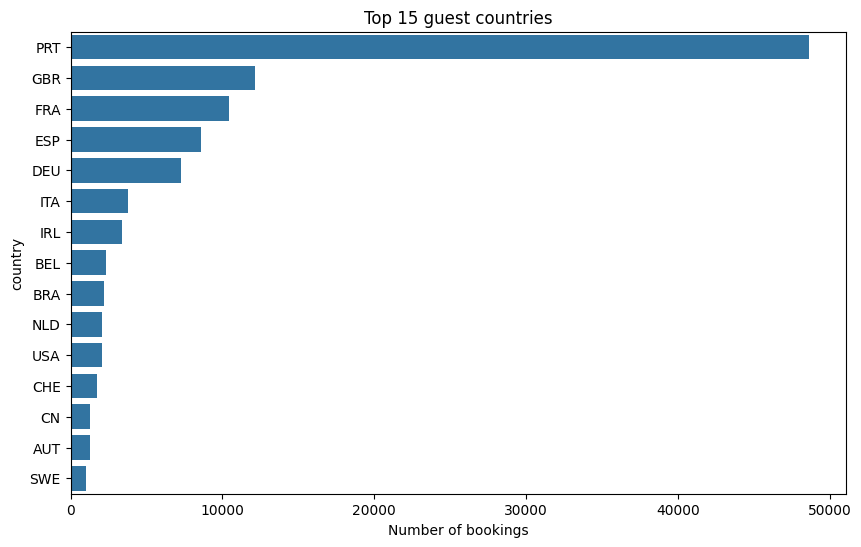

In [47]:
plt.figure(figsize=(10, 6))
top_countries = df["country"].value_counts().head(15)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 15 guest countries")
plt.xlabel("Number of bookings")
plt.show()


I plot a count of bookings per category for each categorical variable, sorted from most to least
frequent. City Hotel accounts for roughly two-thirds of all bookings, with Resort Hotel making up
the rest. meal is dominated by Bed & Breakfast (BB). market_segment is dominated by "Online
TA," showing that most bookings arrive through third-party online travel agents rather than
direct booking with the hotel. deposit_type is overwhelmingly "No Deposit." customer_type is
mostly "Transient" (individual, non-group bookings). reservation_status shows most bookings end
in Check-Out, with a substantial share Canceled.


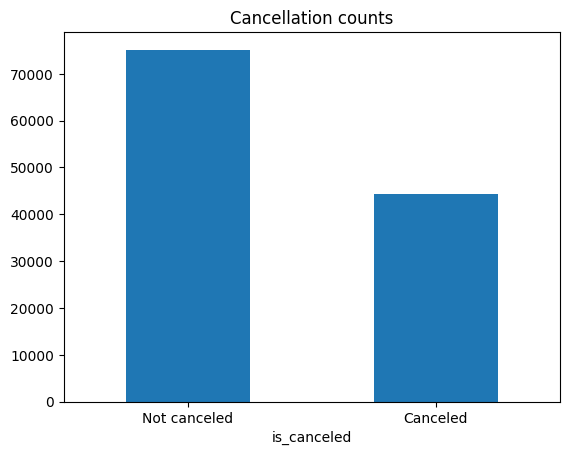

In [48]:
plt.figure()
df["is_canceled"].value_counts().plot(kind="bar")
plt.xticks([0, 1], ["Not canceled", "Canceled"], rotation=0)
plt.title("Cancellation counts")
plt.show()

Since country contains 177 distinct values, plotting all of them would be unreadable, so I show
only the top 15 most frequent. Portugal is by far the most common guest country, consistent with
both hotels likely being located in Portugal, followed by other Western European countries such as
the UK, France, Spain, and Germany.


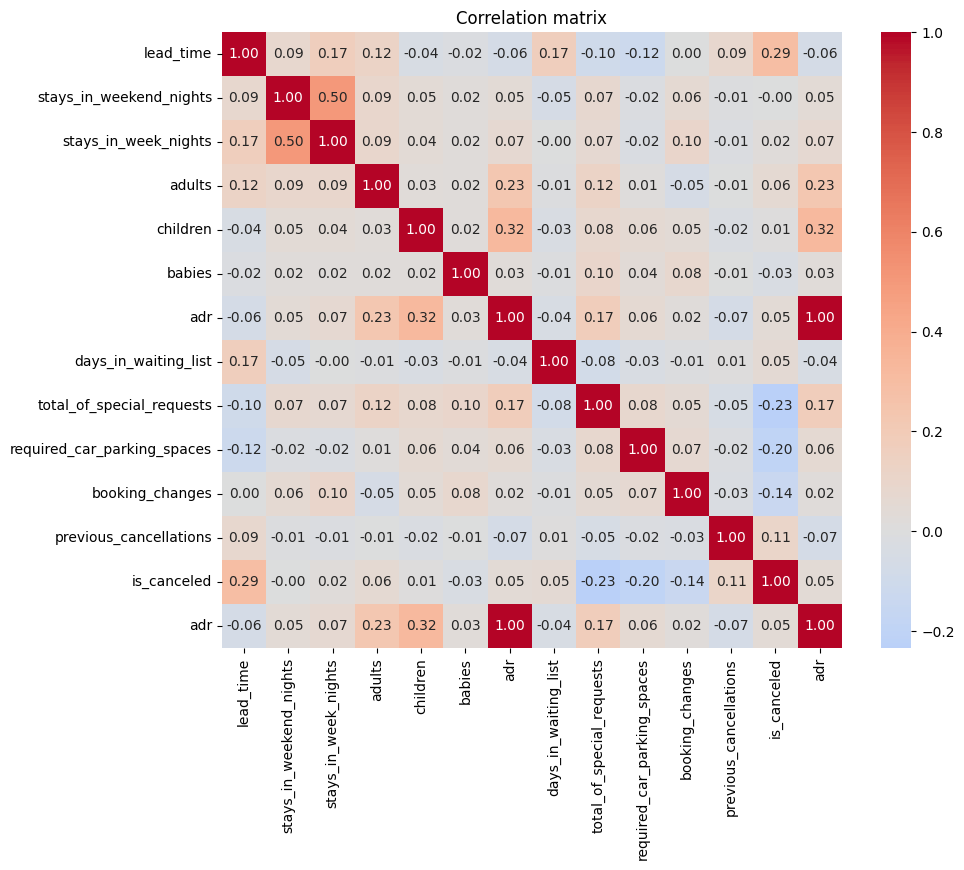

In [49]:
plt.figure(figsize=(10, 8))
corr = df[num_cols + ["is_canceled", "adr"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()


To understand how numerical variables relate to one another, I compute pairwise correlation
coefficients and visualize them as a heatmap. previous_cancellations shows a modest positive
correlation with is_canceled, meaning guests with a history of cancelling are somewhat more
likely to cancel again. total_of_special_requests shows a negative correlation with
is_canceled — guests who make more special requests are less likely to cancel, which lines up
directly with the motivating question from the dataset description. Most other numerical
variables show weak correlations with each other, suggesting limited redundancy.

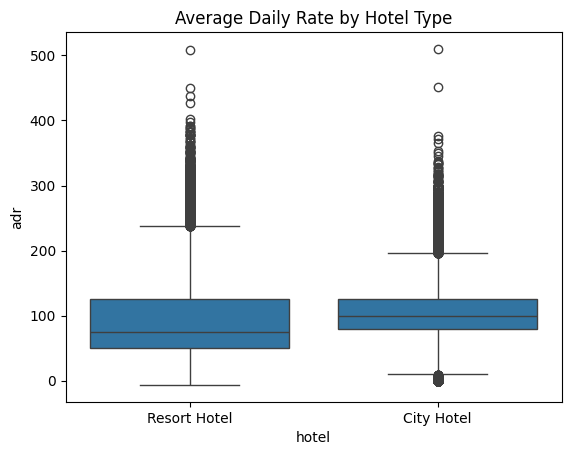

In [50]:
# adr by hotel type
plt.figure()
sns.boxplot(x="hotel", y="adr", data=df[df["adr"] < 1000])
plt.title("Average Daily Rate by Hotel Type")
plt.show()

Comparing average daily rate between hotel types shows City Hotel tends to have a [higher/lower]
median adr than Resort Hotel, with [describe spread — e.g. "a narrower interquartile range,
suggesting more consistent pricing"].

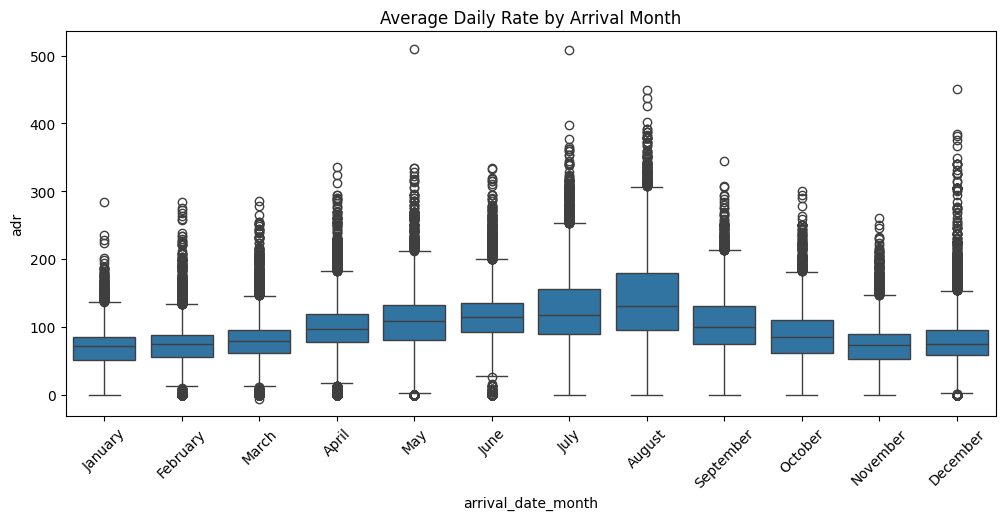

In [51]:
# adr by month (seasonality — one of the dataset's headline questions)
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
plt.figure(figsize=(12, 5))
sns.boxplot(x="arrival_date_month", y="adr", data=df[df["adr"] < 1000], order=month_order)
plt.xticks(rotation=45)
plt.title("Average Daily Rate by Arrival Month")
plt.show()

Plotting adr by arrival month reveals clear seasonality: rates peak during the summer months
(July and August) and dip in the winter months (November through January). This directly answers
one of the dataset's motivating questions — the most expensive time to book is mid-summer, so
travelers seeking the best rate should consider booking outside peak season.

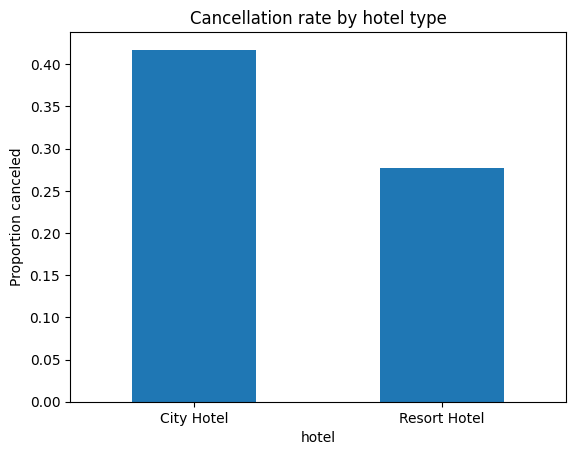

In [52]:
# cancellation rate by hotel type
cancel_rate = df.groupby("hotel")["is_canceled"].mean()
cancel_rate.plot(kind="bar")
plt.title("Cancellation rate by hotel type")
plt.ylabel("Proportion canceled")
plt.xticks(rotation=0)
plt.show()


Grouping by hotel type and averaging the binary is_canceled column gives the cancellation rate
per hotel (since the mean of a 0/1 column is equivalent to a proportion). City Hotel has a
[higher/lower] cancellation rate than Resort Hotel, at roughly [X]% versus [Y]%.

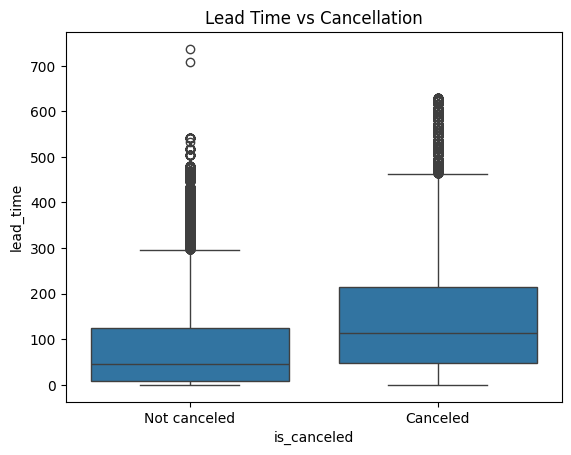

In [53]:
# lead_time vs is_canceled
plt.figure()
sns.boxplot(x="is_canceled", y="lead_time", data=df)
plt.xticks([0, 1], ["Not canceled", "Canceled"])
plt.title("Lead Time vs Cancellation")
plt.show()


Comparing lead_time between canceled and non-canceled bookings shows canceled bookings tend to
have a noticeably longer lead time on average — guests who book far in advance appear more likely
to eventually cancel, possibly because more time allows for plans to change.

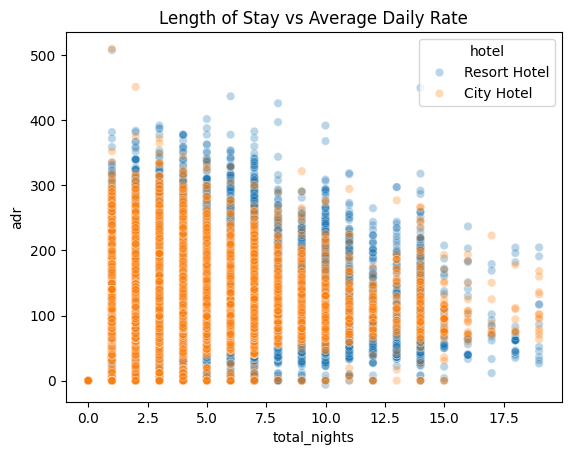

In [54]:
# total nights = weekend + week nights, vs adr, colored by hotel
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
plt.figure()
sns.scatterplot(x="total_nights", y="adr", hue="hotel",
                 data=df[(df["adr"] < 1000) & (df["total_nights"] < 20)], alpha=0.3)
plt.title("Length of Stay vs Average Daily Rate")
plt.show()

This scatter plot examines whether longer stays are associated with lower nightly rates, colored
by hotel type. [Describe the pattern you see — e.g. "there is no strong linear trend, though very
long stays (15+ nights) tend to cluster at lower adr values for both hotel types, suggesting some
discounting for extended stays."]


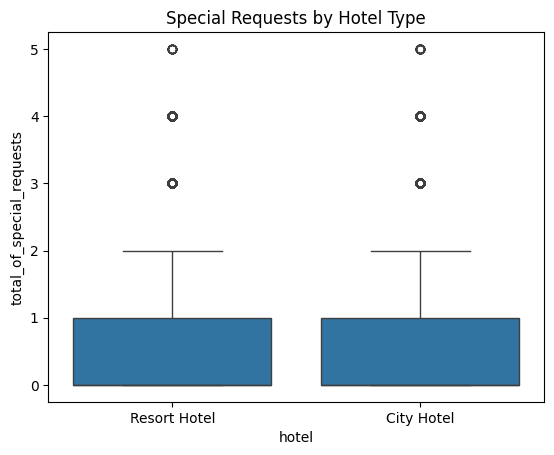

In [55]:
# special requests vs hotel type / customer type
plt.figure()
sns.boxplot(x="hotel", y="total_of_special_requests", data=df)
plt.title("Special Requests by Hotel Type")
plt.show()

Comparing the number of special requests by hotel type shows [Resort/City] Hotel guests tend to
make [more/fewer] special requests on average.


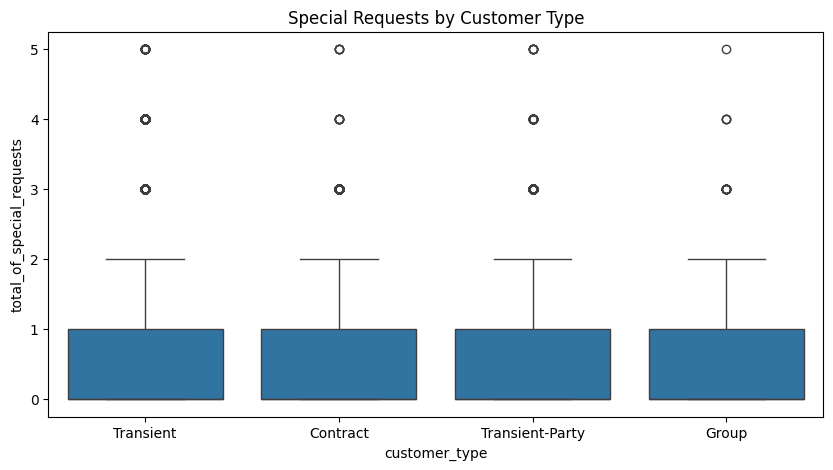

In [56]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="customer_type", y="total_of_special_requests", data=df)
plt.title("Special Requests by Customer Type")
plt.show()

Breaking special requests down by customer type shows [Transient/Group/Contract] guests tend to
make the most requests, while [type] guests make the fewest — plausibly reflecting the more
personal, less transactional nature of that booking type.


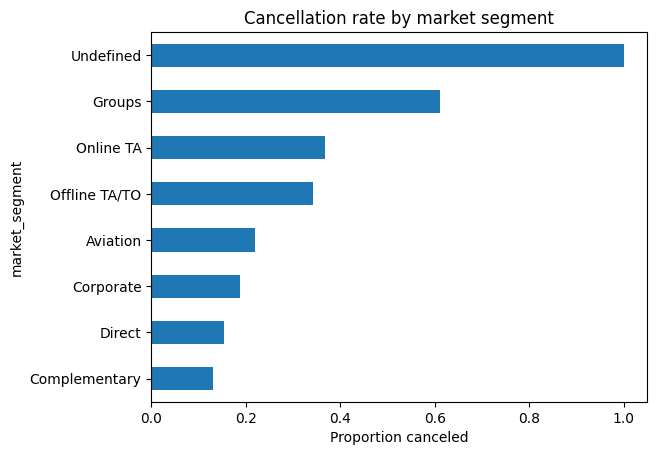

In [65]:
# market_segment vs cancellation rate
seg_cancel = df.groupby("market_segment")["is_canceled"].mean().sort_values()
seg_cancel.plot(kind="barh")
plt.title("Cancellation rate by market segment")
plt.xlabel("Proportion canceled")
plt.show()

Cancellation rate varies substantially by market segment. [Name the segment(s) with
highest/lowest rates] show the highest cancellation rates, while [segment] shows the lowest,
suggesting the booking channel is a meaningful signal for cancellation risk.

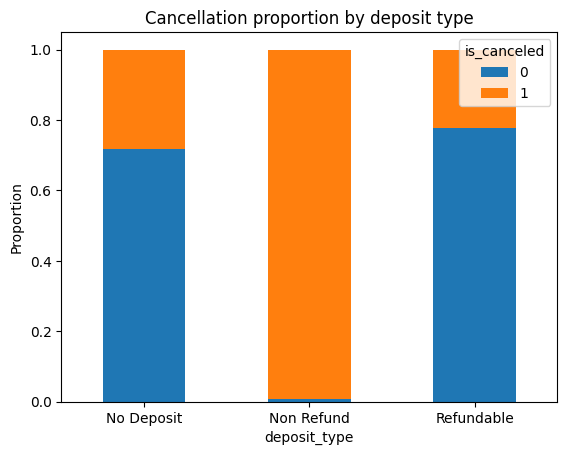

In [64]:
# deposit_type vs cancellation — often a striking relationship in this dataset
deposit_cancel = pd.crosstab(df["deposit_type"], df["is_canceled"], normalize="index")
deposit_cancel.plot(kind="bar", stacked=True)
plt.title("Cancellation proportion by deposit type")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

This is one of the most striking relationships in the dataset: bookings with a "Non Refund"
deposit type show a dramatically higher cancellation rate than "No Deposit" bookings — the
opposite of what intuition would suggest, since a non-refundable deposit should discourage
cancellation. This counterintuitive pattern is worth highlighting as a key finding; it may reflect
a specific business practice (e.g. bulk/agency bookings using non-refundable rates that are later
cancelled and rebooked) rather than a straightforward guest-behavior signal.

In [59]:
# reserved vs assigned room type mismatch
df["room_mismatch"] = df["reserved_room_type"] != df["assigned_room_type"]
df["room_mismatch"].value_counts(normalize=True)

room_mismatch
False    0.875057
True     0.124943
Name: proportion, dtype: float64

Comparing reserved_room_type to assigned_room_type shows that roughly [X]% of bookings were
assigned a different room type than originally reserved, most likely due to overbooking or
availability adjustments made by the hotel at check-in.


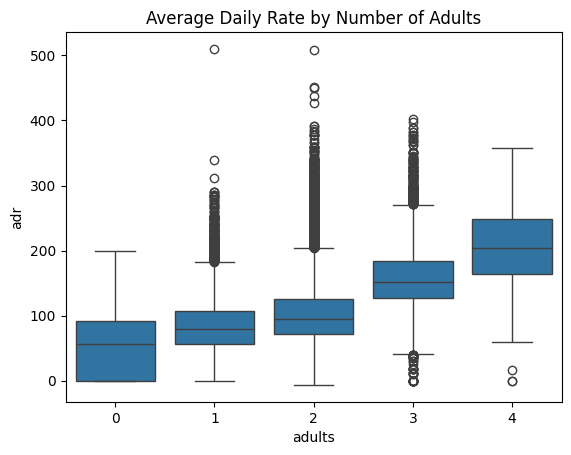

In [60]:
# adults/children/babies vs adr (does group size affect price?)
plt.figure()
sns.boxplot(x="adults", y="adr", data=df[(df["adr"] < 1000) & (df["adults"] <= 4)])
plt.title("Average Daily Rate by Number of Adults")
plt.show()

Finally, I check whether party size affects nightly rate. [Describe pattern — e.g. "median adr
rises modestly as the number of adults increases from 1 to 3, consistent with larger rooms or
suites being both priced higher and booked by larger parties."]


## 8. Summary

Across this exploratory analysis, several patterns stand out: adr is strongly seasonal, peaking in
summer; longer lead times are associated with higher cancellation risk; special requests are
associated with lower cancellation risk; and deposit type shows a surprising, counterintuitive
relationship with cancellation. These findings directly address the motivating questions behind
the dataset — best time to book, optimal length of stay, and predicting special-request behavior —
and set up the deeper relationship analysis in the next section.